In [6]:
import torch
import torch.nn as nn
x = torch.rand(5, 3)
print(x)

tensor([[0.0316, 0.7863, 0.4101],
        [0.2007, 0.6965, 0.5193],
        [0.3455, 0.4297, 0.7132],
        [0.8111, 0.3647, 0.9203],
        [0.5075, 0.5609, 0.5950]])


In [2]:
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))
device = torch.device("cuda")
x = torch.randn(1, 3, dtype=float).to(device)
y = torch.randn(3, 1, dtype=float, device=device)
print(x.shape) 
print(x.dtype)
print(x)
print(y.shape) 
print(y.dtype)
print(y)

True
Tesla T4
torch.Size([1, 3])
torch.float64
tensor([[ 0.1244, -0.8351, -2.0575]], device='cuda:0', dtype=torch.float64)
torch.Size([3, 1])
torch.float64
tensor([[ 0.1003],
        [-0.9390],
        [ 0.3162]], device='cuda:0', dtype=torch.float64)


In [3]:
a = torch.randn(3, 3).to(device)
print(a.dtype)  # should be float32

# Explicit cast
b = a.to(torch.float16)
print(b.dtype)  # float16 - this is what LLMs run in
print(torch.cuda.memory_allocated() / 1024**2, "MB")

torch.float32
torch.float16
0.001953125 MB


In [4]:
def multiply(a, b):
    return a @ b

print(multiply(x, y))

tensor([[0.1460]], device='cuda:0', dtype=torch.float64)


In [5]:
x = torch.randn(4, device='cuda')
y = torch.randn(4, device='cuda')
print(multiply(x, y))        # dot product - should be scalar
print(multiply(x, y).shape)  # what shape is it?

A = torch.randn(3, 4, device='cuda')
print(multiply(A, x))        # matrix-vector - should be shape (3,)
print(multiply(A, x).shape)

tensor(3.3913, device='cuda:0')
torch.Size([])
tensor([1.7631, 1.0244, 0.8416], device='cuda:0')
torch.Size([3])


In [6]:
x = torch.tensor(4.0, requires_grad=True)
y = 3*x**2 + 2*x + 1

# what pytorch recorded - the last operation
print(y.grad_fn)

# one step back
print(y.grad_fn.next_functions)

# two steps back
print(y.grad_fn.next_functions[0][0].next_functions)

# three steps back
print(y.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)

((<AddBackward0 object at 0x7e5539d00b50>, 0), (None, 0))
((<MulBackward0 object at 0x7e5539d00b50>, 0), (<MulBackward0 object at 0x7e5539aaac50>, 0))
((<PowBackward0 object at 0x7e5539acfd60>, 0), (None, 0))


In [7]:
y = x * x
print(y.grad_fn.next_functions)
# Output: ((<AccumulateGrad object at ...>, 0), (<AccumulateGrad object at ...>, 0))

((<AccumulateGrad object at 0x7e565e6aa500>, 0), (<AccumulateGrad object at 0x7e565e6aa500>, 0))


In [8]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')

slope_weight = torch.randn(1, device="cuda", requires_grad=True)
bias_weight = torch.randn(1, device="cuda", requires_grad=True)

for step in range(100):
    
    prediction_values = slope_weight * X + bias_weight
    mse = ((prediction_values - y)**2).mean()
    if mse.item() < 0.1:
        print(f"converged at step {step}")
        break
    mse.backward()
    # print(mse)
    learning_rate = 0.3
    with torch.no_grad():
        w1 = (slope_weight.grad)
        w2 = (bias_weight.grad)
        slope_weight -= learning_rate*w1
        bias_weight -= learning_rate*w2
        slope_weight.grad.zero_()
        bias_weight.grad.zero_()
    # print(w1)
    # print(w2)
print(mse)
print(slope_weight)
print(bias_weight)

converged at step 3
tensor(0.0526, device='cuda:0', grad_fn=<MeanBackward0>)
tensor([1.9476], device='cuda:0', requires_grad=True)
tensor([2.7851], device='cuda:0', requires_grad=True)


In [9]:
X = torch.randn(100, 1, device='cuda')
y = 2 * X + 3 + 0.1 * torch.randn(100, 1, device='cuda')
linear_model = nn.Linear(1, 1, device="cuda")
learning_rate = 0.3
optimizer = torch.optim.SGD(params=linear_model.parameters(), lr=learning_rate)
for step in range(1000):
    loss = ((linear_model(X) - y)**2).mean()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print(f"Learned Slope (Weight): {linear_model.weight.item():.4f}")
print(f"Learned Intercept (Bias): {linear_model.bias.item():.4f}")

test_x = torch.tensor([[10.0]], device="cuda")
with torch.no_grad():
    prediction = linear_model(test_x)
    print(f"Prediction for x=10: {prediction.item():.4f}")

Learned Slope (Weight): 1.9964
Learned Intercept (Bias): 3.0172
Prediction for x=10: 22.9812


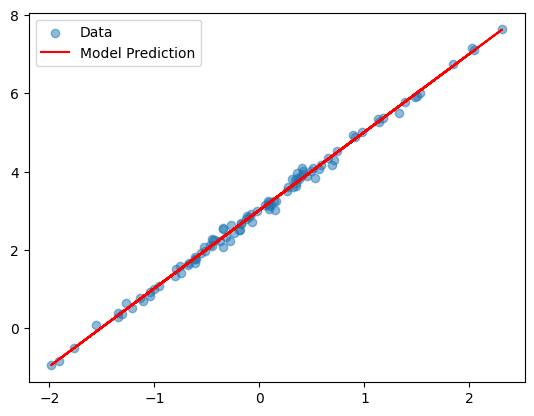

In [10]:
import matplotlib.pyplot as plt

# 1. Move to CPU and convert to NumPy
# .detach() is like saying "cut the umbilical cord to the graph"
X_cpu = X.cpu().numpy()
y_cpu = y.cpu().numpy()

with torch.no_grad():
    predictions_cpu = linear_model(X).cpu().numpy()

# 2. Plot the original "Noisy" dots
plt.scatter(X_cpu, y_cpu, label="Data", alpha=0.5)

# 3. Plot the "Learned" line
plt.plot(X_cpu, predictions_cpu, color='red', label="Model Prediction")
plt.legend()
plt.show()

In [11]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

x1 = np.array([10, 20])          # shape (2,)
x2 = np.array([[10], [20]])      # shape (2,1)

out1 = A @ x1
out2 = A @ x2

print(out1, out1.shape)
print(out2, out2.shape)

[ 50 110] (2,)
[[ 50]
 [110]] (2, 1)


In [12]:
x1 = np.array([50, 110])       # shape (2,)
x2 = np.array([[50], [110]])   # shape (2,1)

print(x1[0])     # what do you get?
print(x2[0])     # what do you get?

50
[50]


In [13]:
tensorX = torch.randn(3, 2)
tensorY = torch.randn(2, 5)

vectorX = torch.randn(3)
vectorY = torch.randn(3)

batchX = torch.randn(6, 3, 2)
batchY = torch.randn(6, 2, 5)

queryM = torch.randn(5, 3, 5)
keyM = torch.randn(5, 3, 5)
#dot product
torch.einsum('i, i->', vectorX, vectorY)

#matrix multiply
torch.einsum('ij,jk->ik', tensorX, tensorY)

#batch matrix multiply
torch.einsum('bij, bjk -> bik', batchX, batchY)

#outer product
torch.einsum('i, j->ij', vectorX, vectorY)

#attention scores
torch.einsum('bij, bkj -> bik', queryM, keyM)

tensor([[[-1.3690e+00,  5.3533e-01, -1.1597e+00],
         [ 1.2432e+00,  5.9682e-01, -6.0321e-01],
         [-6.3754e-01,  1.8414e+00, -1.6095e+00]],

        [[ 1.8661e+00, -2.1948e+00,  7.1459e-02],
         [ 1.0762e+00,  1.1977e+00, -1.2949e+00],
         [-1.1524e+00, -2.3932e+00, -4.0614e+00]],

        [[ 1.9041e+00, -4.9780e-01, -2.9877e-01],
         [ 2.2370e-03, -3.7139e+00,  4.9781e-01],
         [-6.2339e-01, -7.6188e+00,  6.1138e-01]],

        [[ 1.0593e+00, -1.0482e+00, -4.8583e+00],
         [-2.3006e+00,  1.7242e+00,  5.0337e+00],
         [-6.5750e-01,  2.0438e+00,  4.3483e+00]],

        [[-6.9931e-01, -6.0566e+00,  2.9883e+00],
         [-1.1603e+00, -7.9636e-01,  4.6535e-02],
         [ 1.3401e+00, -2.0115e+00,  4.0101e+00]]])

In [14]:
randTensorX = torch.randn(3, 2)
randTensorY = torch.randn(3, 1)

print(randTensorX.shape[0])
# torch.utils.data.dataset()

class RandomDataSet(torch.utils.data.Dataset):
    def __init__(self, tensor1, tensor2):
        self.tensor1 = tensor1
        self.tensor2 = tensor2
    
    def __len__(self):
        return self.tensor1.shape[0]
    
    def __getitem__(self, index):
        return [self.tensor1[index], self.tensor2[index]]

dataSet = RandomDataSet(tensor1=randTensorX, tensor2=randTensorY)
dataLoader = torch.utils.data.DataLoader(dataSet, batch_size=2, num_workers=5, pin_memory=True)
for interation in iter(dataLoader):
    print(interation[0])
    print(interation[1])


    x = interation[0].to(device)
    y = interation[1].to(device)


3


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


tensor([[ 1.3812,  0.9278],
        [-1.0787,  1.5082]])
tensor([[ 0.8023],
        [-0.7166]])
tensor([[-0.0906,  1.0964]])
tensor([[0.3801]])


In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B").to("cuda")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [16]:
p_value = 0.9
n = 5
inputs = tokenizer("Hello, my name is", return_tensors="pt").to("cuda")
temperateValue = 0.01
for i in range(n):
    outputs = model.forward(**inputs)
    # next_token = torch.multinomial(torch.softmax((outputs.logits[0, -1, :]/temperateValue), dim=0), num_samples=1)
    sorted_result = torch.sort(torch.softmax(outputs.logits[0, -1, :], dim=0), descending=True)
    sorted_vals = sorted_result.values
    sorted_indices = sorted_result.indices
    # print(sorted_indices)
    vals = torch.cumsum(sorted_vals, dim=0) 
    mask = vals < p_value
    next_token = torch.multinomial(sorted_vals[mask==True], num_samples=1)
    # print(next_token)
    next_token = sorted_indices[next_token]
    inputs["input_ids"] = torch.cat((inputs["input_ids"], next_token.reshape(1,1)), dim=1)
    # print(type(outputs.past_key_values))
    # print(len(outputs.past_key_values))
    # print(inputs["input_ids"])
    # inputs += (output)
# outputs = model.generate(**inputs, max_new_tokens=25)
print(tokenizer.decode(inputs["input_ids"][0]))
# print(tokenizer.decode(next_token_id=))
# !nvidia-smi

Hello, my name is Geaya and and


In [17]:
import torch.nn.functional as F
seq_len = 8
vocab_size = 50
fake_logits = torch.randn(seq_len, vocab_size)
fake_targets = torch.randint(0, vocab_size, (seq_len,))
prompt_length = 3

per_token_loss = F.cross_entropy(fake_logits, fake_targets, reduction='none')
mask = torch.arange(1, seq_len+1) > prompt_length
new_per_token_loss = per_token_loss[mask]
new_per_token_loss.mean()

tensor(4.8036)

In [18]:
import gym
env = gym.make('CartPole-v1')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-pack

In [19]:
#policy network
class PolicyNetwork(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        #input to hidden
        self.input_layer = nn.Linear(4, 128)
        #hidden to output
        self.output_layer = nn.Linear(128, 2)
    def forward(self, x):
        input_forward = self.input_layer(x)
        activation = torch.relu(input_forward)
        output_forward = self.output_layer(activation)
        return output_forward.softmax(dim=-1)

In [20]:
model = PolicyNetwork()
state = torch.randn(4)
probs = model(state)
print(probs)

tensor([0.4886, 0.5114], grad_fn=<SoftmaxBackward0>)


In [22]:
new_policy = PolicyNetwork()
learning_rate = 0.3
optimizer = torch.optim.Adam(params=new_policy.parameters(), lr=1e-3)
for step in range(500):
    state = env.reset()
    done = False
    log_probs = []
    rewards = []
    entropies = []
    while not done:
        probs = new_policy(torch.tensor(state))
        action = torch.multinomial(probs, num_samples=1)
        log_prob = torch.log(probs[action.item()])
        log_probs.append(log_prob)
        entropies.append(-(probs * torch.log(probs)).sum())
        state, reward, done, info = env.step(action.item()) 
        rewards.append(reward)
    print(f"Episode {step}, reward: {sum(rewards)}")
    new_rewards = []
    for i in range(len(rewards)-1, -1, -1):
        new_rewards.append(sum(rewards[i:]))
    new_rewards = new_rewards[::-1]
    new_rewards = torch.tensor(new_rewards)
    new_rewards = new_rewards - new_rewards.mean()
    loss = sum([-log_probs[i] * new_rewards[i] for i in range(len(rewards))])
    beta = 0.01
    loss = loss - beta * sum(entropies)
    
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

Episode 0, reward: 16.0
Episode 1, reward: 14.0
Episode 2, reward: 33.0
Episode 3, reward: 26.0
Episode 4, reward: 12.0
Episode 5, reward: 18.0
Episode 6, reward: 38.0
Episode 7, reward: 9.0
Episode 8, reward: 35.0
Episode 9, reward: 72.0
Episode 10, reward: 19.0
Episode 11, reward: 26.0
Episode 12, reward: 19.0
Episode 13, reward: 16.0
Episode 14, reward: 18.0
Episode 15, reward: 23.0
Episode 16, reward: 78.0
Episode 17, reward: 15.0
Episode 18, reward: 44.0
Episode 19, reward: 35.0
Episode 20, reward: 23.0
Episode 21, reward: 17.0
Episode 22, reward: 17.0
Episode 23, reward: 13.0
Episode 24, reward: 19.0
Episode 25, reward: 27.0
Episode 26, reward: 43.0
Episode 27, reward: 16.0
Episode 28, reward: 14.0
Episode 29, reward: 50.0
Episode 30, reward: 33.0
Episode 31, reward: 22.0
Episode 32, reward: 44.0
Episode 33, reward: 26.0
Episode 34, reward: 14.0
Episode 35, reward: 17.0
Episode 36, reward: 65.0
Episode 37, reward: 35.0
Episode 38, reward: 28.0
Episode 39, reward: 31.0
Episode 40,

KeyboardInterrupt: 

In [23]:
def isPrime(x: int) -> bool:
    for i in range(2, x):
        if x % i == 0:
            return 0
    return 1
def reward(results):
    return torch.tensor([isPrime(x) for x in results]) 

In [24]:
logits = torch.zeros(101, requires_grad=True)  # never overwrite this
learning_rate = 1e-2
optimizer = torch.optim.Adam(params=[logits], lr=learning_rate)#training loop
for step in range(1000):
    probs = torch.softmax(logits, dim=0)            # compute this fresh each step
    samples = torch.multinomial(probs, num_samples=8)
    rewards = reward(samples).float()
    raw_rewards = reward(samples).float()
    if step % 100 == 0:
        print(f"step {step}, avg reward: {raw_rewards.mean().item():.3f}")
    rewards = (rewards - rewards.mean()) / (rewards.std(dim=0) + 1e-4)
    log_probs = torch.log(probs[samples])
    # print(rewards)
    # print(log_probs)
    loss = -1*sum(log_probs*rewards)
    # print(rewards.mean())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



step 0, avg reward: 0.375
step 100, avg reward: 0.500
step 200, avg reward: 0.500
step 300, avg reward: 0.750
step 400, avg reward: 0.750
step 500, avg reward: 0.750
step 600, avg reward: 0.750


KeyboardInterrupt: 

In [2]:
test_cases = [
    # (code, test) pairs
    ("def reverse(s): return s[::-1]", "assert reverse('hello') == 'olleh'"),  # should pass
    ("def reverse(s): return s",        "assert reverse('hello') == 'olleh'"),  # should fail
    ("def reverse(s: ????",             "assert reverse('hello') == 'olleh'"),  # syntax error
    ("def reverse(s):\n while True: pass", "assert reverse('hello') == 'olleh'"), # timeout
    ("def add(a,b): return a+b",        "assert add(2,3) == 5"),               # should pass
]
test_cases

[('def reverse(s): return s[::-1]', "assert reverse('hello') == 'olleh'"),
 ('def reverse(s): return s', "assert reverse('hello') == 'olleh'"),
 ('def reverse(s: ????', "assert reverse('hello') == 'olleh'"),
 ('def reverse(s):\n while True: pass', "assert reverse('hello') == 'olleh'"),
 ('def add(a,b): return a+b', 'assert add(2,3) == 5')]

In [3]:
import subprocess

def reward_function(test_cases):
    rewards = [0] * len(test_cases)
    for i, python_code in enumerate(test_cases):
        python_code = python_code[0] + "\n" + python_code[1]
        # print(python_code)
        # result = subprocess.run(["python", "-c", python_code], capture_output=True, text=True,  timeout=1 )
        try:
            result = subprocess.run(["python", "-c", python_code], capture_output=True, text=True, timeout=1)
            if result.returncode == 0:
                rewards[i] = 1
        except subprocess.TimeoutExpired:
            rewards[i] = 0
    return rewards

print(reward_function(test_cases))


[1, 0, 0, 0, 1]


In [4]:
problems = [
    {"prompt": "Write a function called add that takes two integers and returns their sum.",
     "test": "assert add(2, 3) == 5\nassert add(-1, 1) == 0\nassert add(0, 0) == 0"},
    
    {"prompt": "Write a function called is_even that returns True if a number is even, False otherwise.",
     "test": "assert is_even(4) == True\nassert is_even(3) == False\nassert is_even(0) == True"},
    
    {"prompt": "Write a function called reverse_string that reverses a string.",
     "test": "assert reverse_string('hello') == 'olleh'\nassert reverse_string('a') == 'a'"},
    
    {"prompt": "Write a function called max_of_three that returns the largest of three numbers.",
     "test": "assert max_of_three(1, 2, 3) == 3\nassert max_of_three(5, 5, 5) == 5"},
    
    {"prompt": "Write a function called factorial that returns the factorial of n.",
     "test": "assert factorial(0) == 1\nassert factorial(5) == 120"},
    
    {"prompt": "Write a function called is_palindrome that returns True if a string is a palindrome.",
     "test": "assert is_palindrome('racecar') == True\nassert is_palindrome('hello') == False"},
    
    {"prompt": "Write a function called count_vowels that counts vowels in a string.",
     "test": "assert count_vowels('hello') == 2\nassert count_vowels('aeiou') == 5"},
    
    {"prompt": "Write a function called flatten that flattens a list of lists into a single list.",
     "test": "assert flatten([[1,2],[3,4]]) == [1,2,3,4]\nassert flatten([[1],[2],[3]]) == [1,2,3]"},
]

system = "You are a Python coding assistant. Return ONLY the Python function, no explanation, no markdown, no code blocks. Just the raw Python code."
num_return_sequences=8
    

In [ ]:
problems = [
    {"prompt": "Write a function called add that takes two integers and returns their sum.",
     "test": "assert add(2, 3) == 5\nassert add(-1, 1) == 0\nassert add(0, 0) == 0"}
]

system = "You are a Python coding assistant. Return ONLY the Python function, no explanation, no markdown, no code blocks. Just the raw Python code."
num_return_sequences=2
    

In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B", dtype=torch.bfloat16).to("cuda")

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [8]:
import re
def extract_code(text):
    # try markdown code block first
    match = re.search(r'```python\n(.*?)```', text, re.DOTALL)
    if match:
        return match.group(1).strip()
    # fall back to finding def ... to end of text
    match = re.search(r'(def \w+.*)', text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""

In [9]:
print(next(model.parameters()).dtype)

torch.bfloat16


In [10]:
def get_per_token_logps(logits, input_ids):
    per_token_logps = []
    for logits_row, input_ids_row in zip(logits, input_ids):
        log_probs = logits_row.log_softmax(dim=-1)
        token_log_prob = torch.gather(log_probs, dim=1, index=input_ids_row.unsqueeze(1)).squeeze(1)
        per_token_logps.append(token_log_prob)
    return torch.stack(per_token_logps)

In [ ]:
num_epochs = 50
n = 50
learning_rate = 1e-5
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)#training loop
all_epoch_rewards = []
for epoch in range(num_epochs):
    epoch_rewards = []
    for problem in problems:
        test_cases = []
        prompt = system + problem["prompt"]
        # print(prompt)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.inference_mode():
            outputs = model.generate(**inputs, max_new_tokens=64, do_sample=True, temperature=0.9, num_return_sequences=num_return_sequences)
        torch.cuda.empty_cache()
        # decode only the generated part, not the prompt
        outputs = outputs.clone()
        generated = outputs[:, inputs["input_ids"].shape[1]:]
        answers = [extract_code(tokenizer.decode(g, skip_special_tokens=True)) for g in generated]
        if epoch % n == 0: 
          print(answers[0])
          torch.save(model.state_dict(), 'checkpoint.pt')
        # print(prompt, answers)
        test_cases = [[answers[i], problem["test"]] for i in range(len(answers))]

        rewards = reward_function(test_cases)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        average = torch.mean(rewards)
        #loss loop
        losses = []
        prompt_length = inputs["input_ids"].shape[1]
        for i in range(num_return_sequences):
            forward_pass = model(outputs[i:i+1])
            logits = forward_pass.logits
            logits = logits[:, :-1, :]        # drop last logit
            input_ids = outputs[i:i+1][:, 1:] # drop first token
            per_token_losses = get_per_token_logps(logits, input_ids)
            per_token_losses = per_token_losses * -1 * (rewards[i] - average)
            per_token_losses = per_token_losses[:, prompt_length-1:]
            losses.append((per_token_losses.sum()))


        # print(f"problem: {problem['prompt'][:30]}... rewards: {rewards.tolist()}, loss: {sum(losses).item():.4f}")
        optimizer.zero_grad()
        sum(losses).backward()
        optimizer.step()
        epoch_rewards.extend(rewards.tolist())
    print(f"epoch {epoch}, avg reward: {sum(epoch_rewards)/len(epoch_rewards):.3f}")
    all_epoch_rewards.append(sum(epoch_rewards)/len(epoch_rewards))


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


def add(a: object, b: object): return (float(a) + float(b))


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 5.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 13.57 GiB is allocated by PyTorch, and 870.03 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
epoch_rewards = [0.388, 0.412, 0.362, 0.312, 0.475, 0.463, 0.475, 0.338, 0.375, 0.362, 0.362, 0.412, 0.400, 0.438, 0.400, 0.350, 0.463, 0.388, 0.412, 0.463, 0.450, 0.375, 0.438, 0.375, 0.312, 0.350, 0.375, 0.412, 0.400, 0.412, 0.425, 0.450, 0.412, 0.388, 0.300, 0.438, 0.263, 0.375, 0.400, 0.475, 0.512, 0.388, 0.487, 0.425, 0.438, 0.325, 0.350, 0.388, 0.362, 0.350]

import matplotlib.pyplot as plt
plt.plot(epoch_rewards)
plt.xlabel('epoch')
plt.ylabel('avg reward')
plt.title('GRPO training curve')
plt.show()